In [ ]:
from fastapi import FastAPI, UploadFile, File
from fastapi.middleware.cors import CORSMiddleware
from fastapi.responses import Response
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchxrayvision as xrv
import os
import gc

# ==========================================
# 1. 커스텀 뼈 제거 AI 아키텍처 (U-Net)
# ==========================================
class LightweightUNet(nn.Module):
    def __init__(self):
        super(LightweightUNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(16))
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32))
        self.pool2 = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.final = nn.Sequential(nn.Conv2d(16, 1, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(self.up2(b))
        d1 = self.dec1(self.up1(d2))
        return self.final(d1)

# 통계적 분포 일치(OOD 방어용) 함수
def match_mean_std(source, template):
    s_mean, s_std = source.mean(), source.std()
    t_mean, t_std = template.mean(), template.std()
    matched = (source - s_mean) * (t_std / (s_std + 1e-8)) + t_mean
    return np.clip(matched, 0, 255).astype(np.uint8)

# ==========================================
# 2. FastAPI 앱 및 AI 모델 초기화 (서버 켤 때 1번만 실행)
# ==========================================
app = FastAPI(title="Lung-Ai Preprocessing API")

# React(웹) 프론트엔드에서 파이썬 서버로 접근할 수 있도록 CORS 허용
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"], 
    allow_methods=["*"], 
    allow_headers=["*"]
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 [Lung-Ai Server] 모델을 {device}에 로드하는 중...")

# 모델 메모리 상주
seg_model = xrv.baseline_models.chestx_det.PSPNet().to(device).eval()
bone_model = LightweightUNet().to(device)
bone_model_path = "lumora_bone_model.pth"

if os.path.exists(bone_model_path):
    bone_model.load_state_dict(torch.load(bone_model_path, map_location=device))
    print("✅ [Lung-Ai Server] 뼈 제거 AI 장착 완료!")
else:
    print("⚠️ [주의] lumora_bone_model.pth 파일이 없습니다.")
bone_model.eval()

# ==========================================
# 3. 실제 API 엔드포인트 (React에서 사진이 올 때마다 실행)
# ==========================================
@app.post("/api/preprocess")
async def run_lung_ai(file: UploadFile = File(...)):
    # 1. React에서 보낸 파일 읽기
    contents = await file.read()
    nparr = np.frombuffer(contents, np.uint8)
    raw_img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)

    if raw_img is None:
        return Response(status_code=400, content="Invalid Image")

    # 2. 512 고해상도 리사이즈 및 정규화
    img_512 = cv2.resize(raw_img, (512, 512))
    img_512_norm = xrv.datasets.normalize(img_512, 255)
    img_tensor = torch.from_numpy(img_512_norm).float().unsqueeze(0).unsqueeze(0).to(device)

    # 3. 딥러닝 연산 전처리 파이프라인
    with torch.no_grad():
        # ① 폐 분할 (Segmentation)
        preds_seg = seg_model(img_tensor)
        left_lung = torch.sigmoid(preds_seg[:, 4, :, :]) > 0.7
        right_lung = torch.sigmoid(preds_seg[:, 5, :, :]) > 0.7
        mask_np = ((left_lung | right_lung).float().cpu().numpy()[0] * 255).astype(np.uint8)

        # ② 마스크 보정 (배경 노이즈 억제)
        contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        m_clean = np.zeros_like(mask_np)
        if len(contours) > 0:
            contours = sorted(contours, key=cv2.contourArea, reverse=True)
            cv2.drawContours(m_clean, contours[:2], -1, 255, thickness=cv2.FILLED)
            m_clean = cv2.dilate(m_clean, np.ones((15, 15), np.uint8), iterations=1)

        # ③ 뼈 억제 모델(U-Net) 입력 준비
        seg_img_512 = cv2.bitwise_and(img_512, img_512, mask=m_clean)
        img_224 = cv2.resize(seg_img_512, (224, 224))
        bone_input = torch.from_numpy(img_224).float().unsqueeze(0).unsqueeze(0).to(device) / 255.0

        # ④ 뼈 억제 수행
        bone_out_224 = (bone_model(bone_input).cpu().numpy()[0, 0, :, :] * 255).astype(np.uint8)

        # ⑤ 최종 복원 (Soft Blending + 배경 복구 + 분포 일치)
        bone_out_512 = cv2.resize(bone_out_224, (512, 512))
        blended = cv2.addWeighted(bone_out_512, 0.3, img_512, 0.7, 0)
        
        alpha = cv2.GaussianBlur(m_clean, (31, 31), 0).astype(float) / 255.0
        final_img = (alpha * blended + (1 - alpha) * img_512).astype(np.uint8)
        
        # OOD 방어: 픽셀 분포 맞추기
        final_processed_img = match_mean_std(final_img, img_512)

    # 4. GPU 메모리 반납
    del img_tensor, preds_seg, bone_input
    torch.cuda.empty_cache()
    gc.collect()

    # 5. 전처리된 이미지를 웹이 읽을 수 있는 PNG 포맷 바이트로 인코딩하여 반환!
    _, encoded_img = cv2.imencode('.png', final_processed_img)
    return Response(content=encoded_img.tobytes(), media_type="image/png")

c:\Users\whdeh\Documents\대학교 3학년\융합설계 및 프로젝트기본\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



[Lung-Ai Pro] 🔥 현재 활성화된 연산 장치: CPU
[Lung-Ai Pro] ✅ 자체 학습 뼈 제거 가중치 장착 완료!
[Lung-Ai Pro] ✅ 로컬 비전 AI 준비 완료! (llama3.2-vision)


SyntaxError: 'return' outside function (1872221011.py, line 241)


[Lung-Ai Pro] 🔥 현재 활성화된 연산 장치: CPU
[Lung-Ai Pro] ✅ 자체 학습 뼈 제거 모델 로드 완료!
[Lung-Ai Pro] ✅ 로컬 비전 AI (QA Report) 준비 완료! (llama3.2-vision)

🚀 총 5장 '고해상도 소프트 블렌딩 데모' 가동 중 (배치: 4)


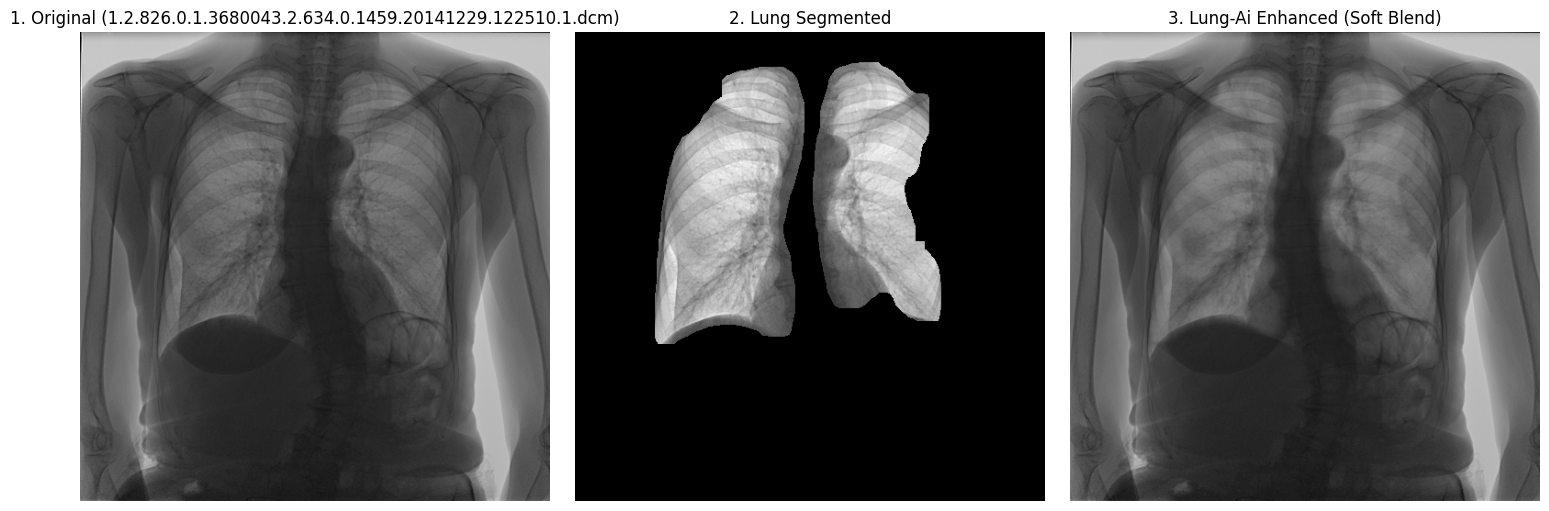

🔄 [1.2.826.0.1.3680043.2.634.0.1459.20141229.122510.1.dcm] AI 시각적 분석 리포트 백그라운드 생성 중...


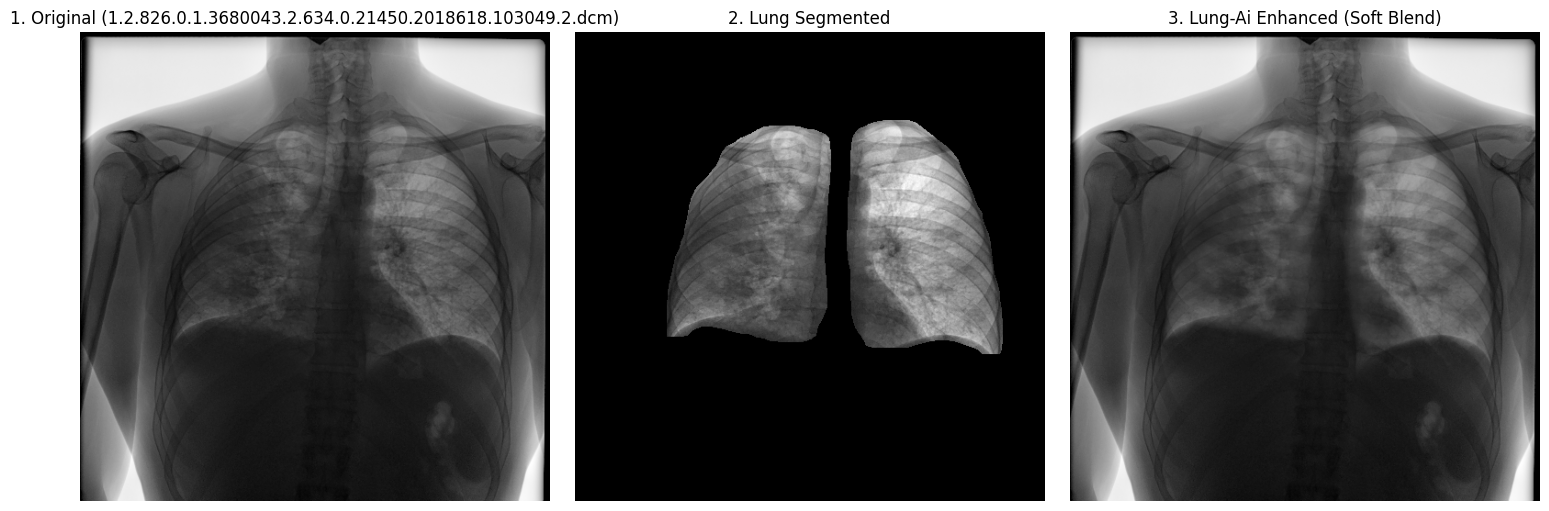

🔄 [1.2.826.0.1.3680043.2.634.0.21450.2018618.103049.2.dcm] AI 시각적 분석 리포트 백그라운드 생성 중...


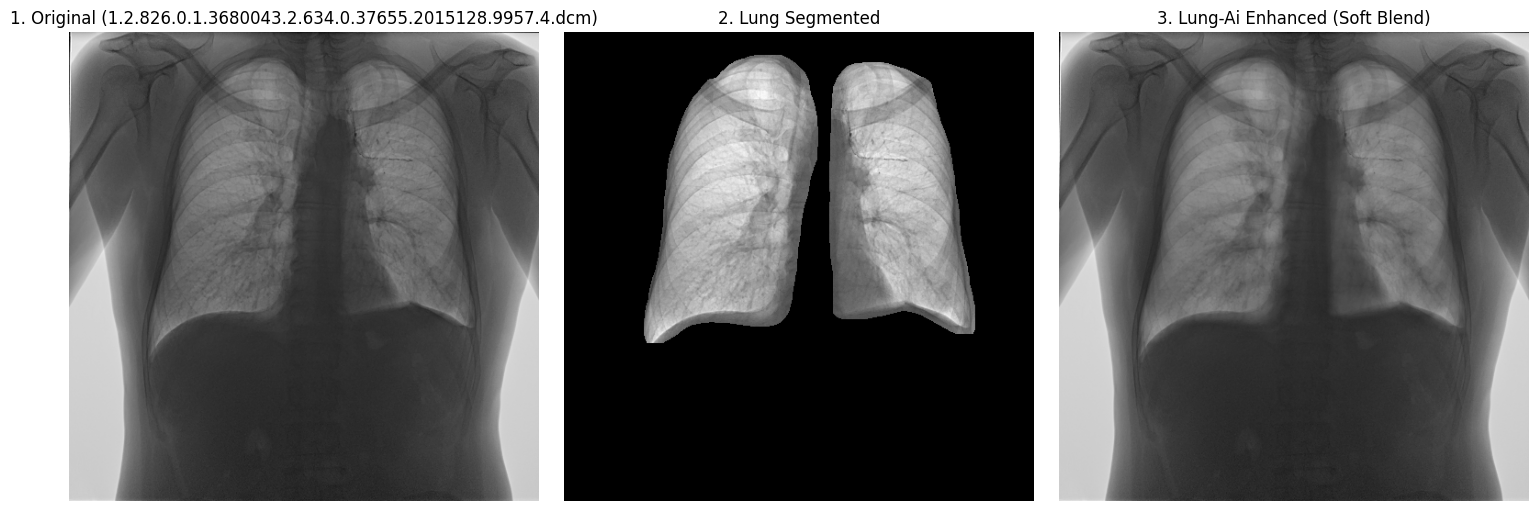

🔄 [1.2.826.0.1.3680043.2.634.0.37655.2015128.9957.4.dcm] AI 시각적 분석 리포트 백그라운드 생성 중...


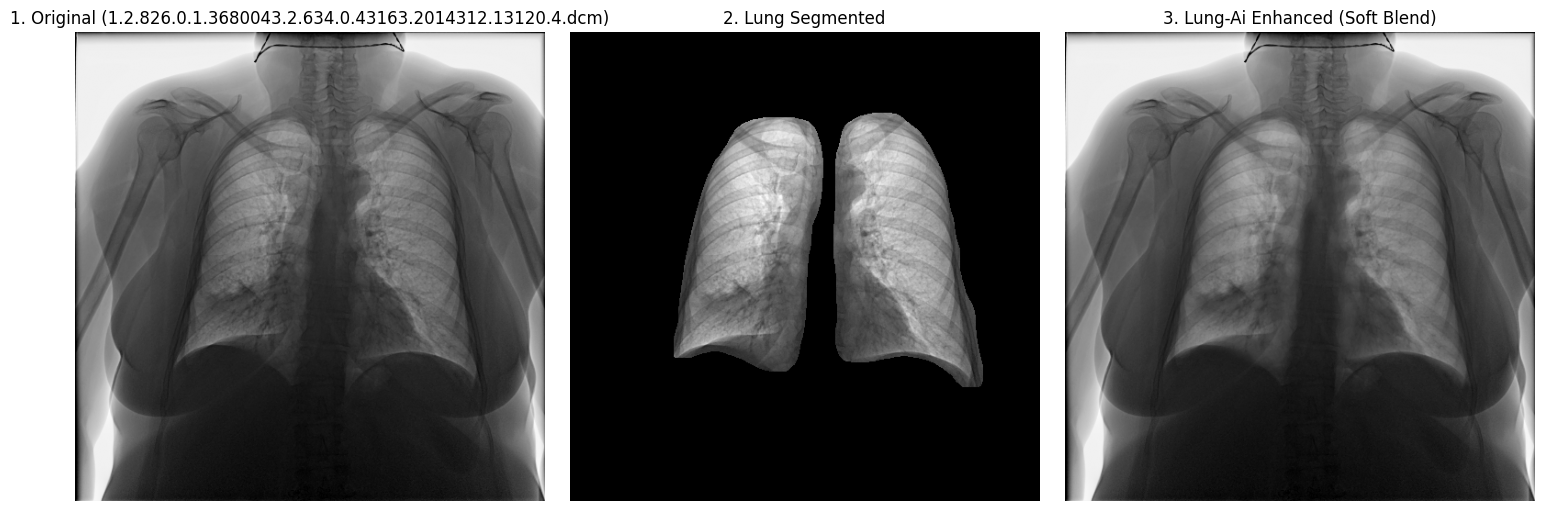

🔄 [1.2.826.0.1.3680043.2.634.0.43163.2014312.13120.4.dcm] AI 시각적 분석 리포트 백그라운드 생성 중...


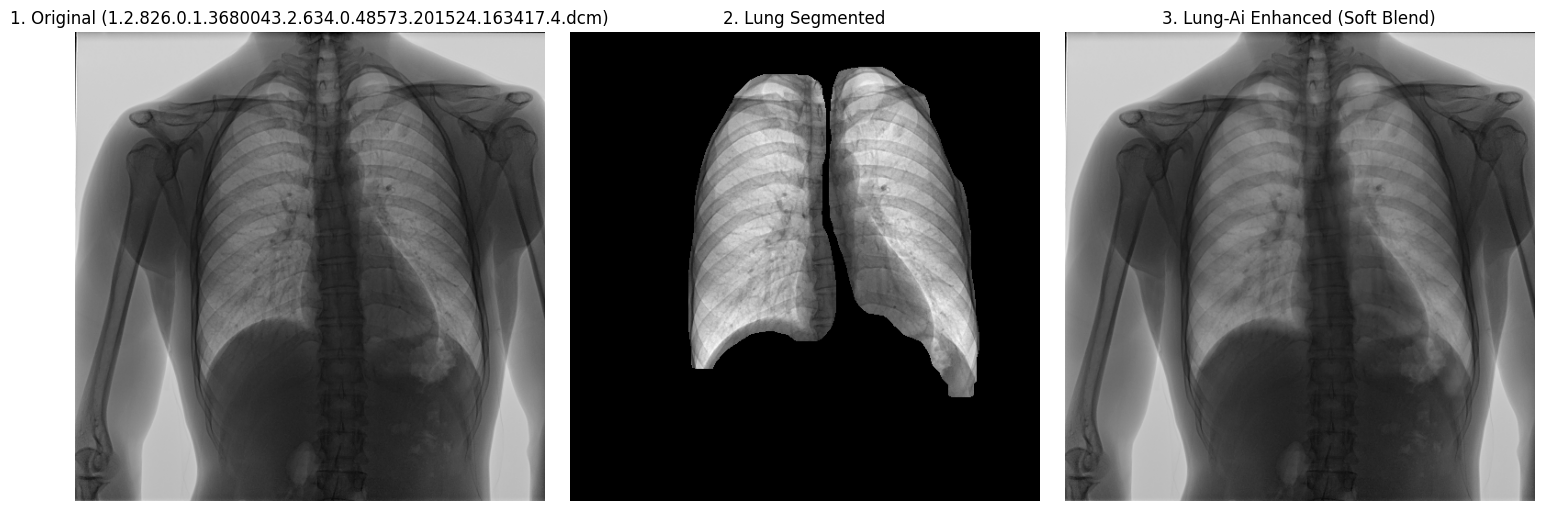

🔄 [1.2.826.0.1.3680043.2.634.0.48573.201524.163417.4.dcm] AI 시각적 분석 리포트 백그라운드 생성 중...

⏳ 모든 전처리 및 화면 출력이 완료되었습니다. 작성 완료된 QA 리포트를 수합합니다...
❌ 1.2.826.0.1.3680043.2.634.0.1459.20141229.122510.1.dcm 로컬 추론 에러: llama-server process has terminated: exit status 1: error loading model: unknown model architecture: 'mllama'
error loading model: unknown model architecture: 'mllama' (status code: 500)
❌ 1.2.826.0.1.3680043.2.634.0.21450.2018618.103049.2.dcm 로컬 추론 에러: llama-server process has terminated: exit status 1: error loading model: unknown model architecture: 'mllama'
error loading model: unknown model architecture: 'mllama' (status code: 500)
❌ 1.2.826.0.1.3680043.2.634.0.37655.2015128.9957.4.dcm 로컬 추론 에러: llama-server process has terminated: exit status 1: error loading model: unknown model architecture: 'mllama'
error loading model: unknown model architecture: 'mllama' (status code: 500)
❌ 1.2.826.0.1.3680043.2.634.0.43163.2014312.13120.4.dcm 로컬 추론 에러: llama-server process has terminated:

In [2]:
import pydicom
import cv2
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchxrayvision as xrv
import matplotlib.pyplot as plt
import glob
import os
import gc
import io
import warnings
from PIL import Image
import ollama 
from tqdm import tqdm
import concurrent.futures

# 불필요한 경고창 차단 (깔끔한 터미널 출력용)
warnings.filterwarnings("ignore")

# ==========================================
# 1. 커스텀 뼈 제거 AI 아키텍처
# ==========================================
class LightweightUNet(nn.Module):
    def __init__(self):
        super(LightweightUNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(16))
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32))
        self.pool2 = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.final = nn.Sequential(nn.Conv2d(16, 1, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(self.up2(b))
        d1 = self.dec1(self.up1(d2))
        return self.final(d1)

# ==========================================
# 2. 고해상도(512x512) 데이터 로더
# ==========================================
class MedicalImageDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        file_name = os.path.basename(file_path)
        ext = os.path.splitext(file_path)[-1].lower()

        # 다이콤(.dcm)과 일반 이미지(.png, .jpg) 동시 지원
        if ext == '.dcm':
            dicom_data = pydicom.dcmread(file_path)
            pixel_array = dicom_data.pixel_array
            raw_img = cv2.normalize(pixel_array, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
        else:
            img_array = np.fromfile(file_path, np.uint8)
            raw_img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)

        # 디테일 유지를 위해 512x512 고해상도로 처리
        img_512 = cv2.resize(raw_img, (512, 512))
        img_512_norm = xrv.datasets.normalize(img_512, 255)

        return {
            'file_name': file_name,
            'raw_img_512': img_512,
            'img_512_norm': torch.from_numpy(img_512_norm).float().unsqueeze(0)
        }

# ==========================================
# 3. 최신 기술이 탑재된 LungAiEngine
# ==========================================
class LungAiEngine: 
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"\n[Lung-Ai Pro] 🔥 현재 활성화된 연산 장치: {str(self.device).upper()}")
        
        self.seg_model = xrv.baseline_models.chestx_det.PSPNet().to(self.device).eval()
        self.bone_model = LightweightUNet().to(self.device)
        
        if os.path.exists(self.config['bone_model_path']):
            self.bone_model.load_state_dict(torch.load(self.config['bone_model_path'], map_location=self.device))
            print("[Lung-Ai Pro] ✅ 자체 학습 뼈 제거 모델 로드 완료!")
        else:
            print("[Lung-Ai Pro] ⚠️ 주의: 뼈 제거 가중치 파일이 없습니다.")
        self.bone_model.eval()
        
        self.vision_model_name = 'llama3.2-vision'
        print(f"[Lung-Ai Pro] ✅ 로컬 비전 AI (QA Report) 준비 완료! ({self.vision_model_name})")

    def generate_vision_report(self, file_name, noise_ratio, processed_img):
        pil_img = Image.fromarray(processed_img)
        img_byte_arr = io.BytesIO()
        pil_img.save(img_byte_arr, format='PNG')
        img_bytes = img_byte_arr.getvalue()

        prompt = f"""
        당신은 의료 영상 QA 전문가입니다. 첨부된 이미지는 흉부 X-ray를 최신 AI 기법(소프트 블렌딩 앙상블)으로 전처리한 최종 결과물입니다.
        이 이미지를 직접 시각적으로 분석하여 정확히 3줄의 한국어로만 보고서를 작성하세요.
        [보조 데이터] - 파일명: {file_name} / 뼈 및 노이즈 억제율 추정치: {noise_ratio:.2f}%
        1. 첫 번째 줄: 배경 노이즈 제거 및 뼈 억제의 자연스러움(시각적 위화감 여부) 평가.
        2. 두 번째 줄: 폐 조직 내 미세한 질감(결절, 혈관 등)의 보존 상태 평가.
        3. 세 번째 줄: 다음 진단 모델(DenseNet 등) 입력 데이터로 '매우 적합합니다' 또는 '적합하지 않습니다' 선택.
        """
        
        try:
            response = ollama.chat(
                model=self.vision_model_name,
                messages=[{
                    'role': 'user',
                    'content': prompt,
                    'images': [img_bytes]
                }]
            )
            return f"\n" + "-"*60 + f"\n📋 LUNG-AI QA REPORT: {file_name}\n" + "-"*60 + f"\n{response['message']['content'].strip()}\n" + "="*70
        except Exception as e:
            return f"❌ {file_name} 로컬 추론 에러: {e}"

# ==========================================
# 4. 실전 데모 구동부 (비동기 QA + 고해상도 시각화)
# ==========================================
SYSTEM_CONFIG = {
    'folder_path': r"C:\Users\whdeh\Documents\대학교 3학년\융합설계 및 프로젝트기본\archive\dicoms",
    'bone_model_path': "lumora_bone_model.pth",
    'seg_threshold': 0.7,
    'batch_size': 4  
}

engine = LungAiEngine(SYSTEM_CONFIG)
file_list = glob.glob(os.path.join(SYSTEM_CONFIG['folder_path'], "*.dcm")) + \
            glob.glob(os.path.join(SYSTEM_CONFIG['folder_path'], "*.png")) + \
            glob.glob(os.path.join(SYSTEM_CONFIG['folder_path'], "*.jpg"))

if len(file_list) > 0:
    target_files = file_list[:5] # 데모를 위해 5장 지정
    print(f"\n🚀 총 {len(target_files)}장 '고해상도 소프트 블렌딩 데모' 가동 중 (배치: {SYSTEM_CONFIG['batch_size']})\n" + "="*70)
    
    dataset = MedicalImageDataset(target_files)
    dataloader = DataLoader(dataset, batch_size=SYSTEM_CONFIG['batch_size'], shuffle=False)

    max_workers = 2 
    report_futures = []
    
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        for batch in dataloader:
            file_names = batch['file_name']
            img_512_norm = batch['img_512_norm'].to(engine.device)
            raw_img_512 = batch['raw_img_512'].numpy()
            
            # -------------------------------------------------
            # [STEP 1] 초고속 512x512 전처리 파이프라인 (GPU 연산)
            # -------------------------------------------------
            with torch.no_grad():
                preds_seg = engine.seg_model(img_512_norm)
                left_lung = torch.sigmoid(preds_seg[:, 4, :, :]) > SYSTEM_CONFIG['seg_threshold']
                right_lung = torch.sigmoid(preds_seg[:, 5, :, :]) > SYSTEM_CONFIG['seg_threshold']
                mask_np = ((left_lung | right_lung).float().cpu().numpy() * 255).astype(np.uint8)

                processed_224_list = []
                mask_512_list = []
                noise_ratios = []

                for i in range(len(file_names)):
                    m_raw = mask_np[i]
                    orig_white = np.sum(m_raw == 255)

                    contours, _ = cv2.findContours(m_raw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                    m_clean = np.zeros_like(m_raw)

                    if contours:
                        contours = sorted(contours, key=cv2.contourArea, reverse=True)
                        cv2.drawContours(m_clean, contours[:2], -1, 255, thickness=cv2.FILLED)
                        m_clean = cv2.morphologyEx(m_clean, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
                        
                        # 자연스러운 경계를 위해 마스크 살짝 팽창
                        m_clean = cv2.dilate(m_clean, np.ones((15, 15), np.uint8), iterations=1)
                        clean_white = np.sum(m_clean == 255)
                    else:
                        clean_white = 0

                    n_ratio = ((orig_white - clean_white) / max(1, orig_white)) * 100
                    noise_ratios.append(n_ratio)

                    mask_512_list.append(m_clean)
                    seg_img_512 = cv2.bitwise_and(raw_img_512[i], raw_img_512[i], mask=m_clean)
                    
                    # 뼈 제거 모델(U-Net) 입력을 위해 224로 축소
                    processed_224_list.append(cv2.resize(seg_img_512, (224, 224)))

                # 뼈 억제 진행
                input_tensor = torch.from_numpy(np.array(processed_224_list)).float().unsqueeze(1).to(engine.device) / 255.0
                bone_out_224 = (engine.bone_model(input_tensor).cpu().numpy()[:, 0, :, :] * 255).astype(np.uint8)

                final_restored_batch = []
                
                # 🔥 SOTA 업그레이드: 해상도 복원 및 소프트 블렌딩
                for i in range(len(bone_out_224)):
                    # 1. 뼈 억제된 이미지를 다시 512 고화질로 뻥튀기
                    bone_out_512 = cv2.resize(bone_out_224[i], (512, 512))
                    
                    # 2. 30% 소프트 블렌딩 (가장 자연스러운 질감 유지)
                    blended_lung = cv2.addWeighted(bone_out_512, 0.3, raw_img_512[i], 0.7, 0)
                    
                    # 3. 배경 완벽 복원 (가우시안 블러 마스크 적용)
                    alpha = cv2.GaussianBlur(mask_512_list[i], (31, 31), 0).astype(float) / 255.0 
                    final_img = (alpha * blended_lung + (1 - alpha) * raw_img_512[i]).astype(np.uint8)
                    
                    final_restored_batch.append(final_img)

            # -------------------------------------------------
            # [STEP 2] GPU 자원 즉시 반납 (Ollama 충돌 방지)
            # -------------------------------------------------
            del img_512_norm, preds_seg, input_tensor
            torch.cuda.empty_cache()
            gc.collect()

            # -------------------------------------------------
            # [STEP 3] 시각화 및 백그라운드 리포트 전송
            # -------------------------------------------------
            for i in range(len(file_names)):
                f_name = file_names[i]
                final_img = final_restored_batch[i]
                
                # 화면에 전/중/후 사진 즉시 출력
                fig = plt.figure(figsize=(15, 5))
                plt.subplot(1, 3, 1); plt.title(f"1. Original ({f_name})"); plt.imshow(raw_img_512[i], cmap='gray'); plt.axis('off')
                
                # 시각화용 분할 이미지 (배경 까맣게 날린 것)
                seg_view = cv2.bitwise_and(raw_img_512[i], raw_img_512[i], mask=mask_512_list[i])
                plt.subplot(1, 3, 2); plt.title("2. Lung Segmented"); plt.imshow(seg_view, cmap='gray'); plt.axis('off')
                
                plt.subplot(1, 3, 3); plt.title("3. Lung-Ai Enhanced (Soft Blend)"); plt.imshow(final_img, cmap='gray'); plt.axis('off')
                plt.tight_layout()
                plt.show() # 이미지가 즉시 표시됨
                
                print(f"🔄 [{f_name}] AI 시각적 분석 리포트 백그라운드 생성 중...")
                
                # Ollama 리포트 생성을 스레드 풀에 던짐 (비동기)
                future = executor.submit(engine.generate_vision_report, f_name, noise_ratios[i], final_img)
                report_futures.append(future)

        print("\n⏳ 모든 전처리 및 화면 출력이 완료되었습니다. 작성 완료된 QA 리포트를 수합합니다...")
        
        # 4. 백그라운드에서 완료된 리포트 출력
        for future in concurrent.futures.as_completed(report_futures):
            print(future.result())
            
    print("\n✅ Lung-Ai 데모 파이프라인 처리가 성공적으로 종료되었습니다.")

else:
    print(f"❌ 지정된 폴더에 테스트할 이미지가 없습니다: {SYSTEM_CONFIG['folder_path']}")


[Lung-Ai Training] 🔥 현재 활성화된 학습 연산 장치: CPU
⚠️ 심각한 경고: GPU가 인식되지 않았습니다. CPU로 학습하면 시간이 매우 오래 걸립니다!
[Dataset] 총 1446개의 학습용 PNG 데이터를 GPU로 보낼 준비 완료.

🚀 Lumora 팀의 'Lung-Ai' 뼈 제거 AI GPU 학습을 시작합니다!
Epoch [1/10] ----- Loss: 0.012085
Epoch [2/10] ----- Loss: 0.004580
Epoch [3/10] ----- Loss: 0.003858
Epoch [4/10] ----- Loss: 0.003542
Epoch [5/10] ----- Loss: 0.003252
Epoch [6/10] ----- Loss: 0.003104
Epoch [7/10] ----- Loss: 0.002910
Epoch [8/10] ----- Loss: 0.002768
Epoch [9/10] ----- Loss: 0.002725
Epoch [10/10] ----- Loss: 0.002697
🎉 GPU AI 모델 학습 완벽 종료!
💾 학습된 가중치가 성공적으로 저장되었습니다: lumora_bone_model.pth


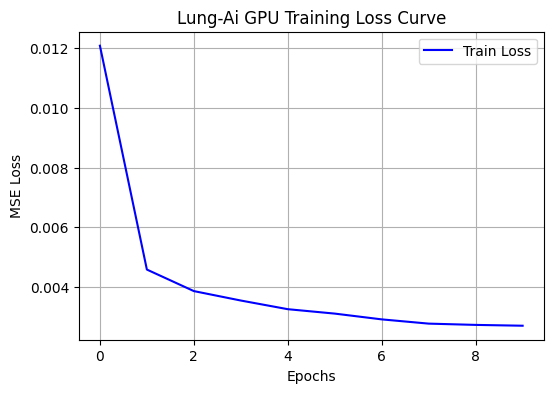

In [ ]:
import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import gc

# ==========================================
# 1. 환경 및 GPU 강제 세팅
# ==========================================
DATA_DIR = r"C:\Users\whdeh\Documents\대학교 3학년\융합설계 및 프로젝트기본\PadChest_GR_progression_prior_studies"
BATCH_SIZE = 8       # RTX 3060 (12GB) VRAM 기준 최적화된 배치 사이즈
EPOCHS = 10         
LEARNING_RATE = 0.001

# 🌟 GPU(CUDA) 강제 할당 및 확인
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n[Lung-Ai Training] 🔥 현재 활성화된 학습 연산 장치: {str(DEVICE).upper()}")
if DEVICE.type == 'cpu':
    print("⚠️ 심각한 경고: GPU가 인식되지 않았습니다. CPU로 학습하면 시간이 매우 오래 걸립니다!")

# ==========================================
# 2. 한글 경로 버그가 패치된 데이터셋 설계
# ==========================================
class PadChestBoneDataset(Dataset):
    def __init__(self, folder_path):
        self.file_list = glob.glob(os.path.join(folder_path, "*.png"))
        if len(self.file_list) == 0:
            raise FileNotFoundError(f"❌ '{folder_path}' 폴더 안에 학습용 .png 파일이 없습니다!")
        print(f"[Dataset] 총 {len(self.file_list)}개의 학습용 PNG 데이터를 GPU로 보낼 준비 완료.")

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        
        # [버그 수정] 한글 경로 우회 로드
        try:
            img_array = np.fromfile(file_path, np.uint8)
            raw_img = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        except Exception as e:
            raise IOError(f"파일 로드 에러: {file_path} / {e}")
            
        raw_img = cv2.resize(raw_img, (224, 224))
        
        # [임시 정답 생성] OpenCV 필터로 뼈를 감쇄시킨 타겟 이미지 제작
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced = clahe.apply(raw_img)
        blurred = cv2.GaussianBlur(enhanced, (21, 21), 0)
        bone_suppressed = cv2.addWeighted(enhanced, 0.7, blurred, 0.3, 0)
        
        # 파이토치 텐서 변환 (0~1 정규화)
        x_tensor = torch.from_numpy(raw_img).float().unsqueeze(0) / 255.0
        y_tensor = torch.from_numpy(bone_suppressed).float().unsqueeze(0) / 255.0
        
        return x_tensor, y_tensor

# ==========================================
# 3. 인공지능 모델 설계도 (U-Net)
# ==========================================
class LightweightUNet(nn.Module):
    def __init__(self):
        super(LightweightUNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(16))
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32))
        self.pool2 = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.final = nn.Sequential(nn.Conv2d(16, 1, 1), nn.Sigmoid())

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(self.up2(b))
        d1 = self.dec1(self.up1(d2))
        return self.final(d1)

# ==========================================
# 4. GPU 풀가동 학습 루프
# ==========================================
dataset = PadChestBoneDataset(DATA_DIR)
# num_workers를 0으로 두어 윈도우 환경에서의 멀티프로세싱 충돌 방지
train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

# 🌟 모델을 GPU 메모리로 업로드!
model = LightweightUNet().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("\n🚀 Lumora 팀의 'Lung-Ai' 뼈 제거 AI GPU 학습을 시작합니다!")
print("="*60)

loss_history = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for inputs, targets in train_loader:
        # 🌟 데이터(사진)를 램(RAM)에서 그래픽카드(VRAM)로 전송!
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch [{epoch+1}/{EPOCHS}] ----- Loss: {epoch_loss:.6f}")
    
    # 🌟 [메모리 최적화] 매 에폭이 끝날 때마다 GPU 쓰레기통을 비워 VRAM 터짐 방지
    torch.cuda.empty_cache()
    gc.collect()

print("="*60)
print("🎉 GPU AI 모델 학습 완벽 종료!")

# ==========================================
# 5. 가중치 저장 및 결과 출력
# ==========================================
MODEL_SAVE_PATH = "lumora_bone_model.pth"
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"💾 학습된 가중치가 성공적으로 저장되었습니다: {MODEL_SAVE_PATH}")

plt.figure(figsize=(6,4))
plt.plot(loss_history, label='Train Loss', color='blue')
plt.title('Lung-Ai GPU Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.grid(True)
plt.legend()
plt.show()

In [3]:
import os
import glob
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchxrayvision as xrv
import gc
import sys
from tqdm import tqdm

# ==========================================
# ⚙️ 1. 환경 설정 
# ==========================================
IMAGE_DIR = r"C:\Users\whdeh\Documents\대학교 3학년\융합설계 및 프로젝트기본\PadChest_GR_progression_prior_studies"
BONE_MODEL_PATH = "lumora_bone_model.pth"
EXCEL_GROUND_TRUTH_PATH = r"C:\Users\whdeh\Documents\대학교 3학년\융합설계 및 프로젝트기본\BIMCV-Padchest-GR\totaldata.xlsx"
OUTPUT_EXCEL_PATH = r"C:\Users\whdeh\Documents\대학교 3학년\융합설계 및 프로젝트기본\Final_AB_Test_Results_PNG.xlsx"

EXCEL_FILENAME_COL = "ImageID"  
BATCH_SIZE = 8     
THRESHOLD = 0.5   # 통합 시스템이므로 임계값은 0.5로 공정하게 고정

# ==========================================
# 🧠 2. 모델 아키텍처
# ==========================================
class LightweightUNet(nn.Module):
    def __init__(self):
        super(LightweightUNet, self).__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(16))
        self.pool1 = nn.MaxPool2d(2, 2)
        self.enc2 = nn.Sequential(nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.BatchNorm2d(32))
        self.pool2 = nn.MaxPool2d(2, 2)
        self.bottleneck = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.ReLU())
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(nn.Conv2d(32, 32, 3, padding=1), nn.ReLU())
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = nn.Sequential(nn.Conv2d(16, 16, 3, padding=1), nn.ReLU())
        self.final = nn.Sequential(nn.Conv2d(16, 1, 1), nn.Sigmoid())
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))
        d2 = self.dec2(self.up2(b))
        d1 = self.dec1(self.up1(d2))
        return self.final(d1)

# ==========================================
# 📂 3. 데이터 로더
# ==========================================
class PNGDataset(Dataset):
    def __init__(self, file_paths, label_dict):
        self.file_paths = file_paths
        self.label_dict = label_dict

    def __len__(self): return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        file_name = os.path.basename(file_path)
        basename = os.path.splitext(file_name)[0]

        label_text = self.label_dict.get(file_name, self.label_dict.get(basename, "normal"))
        cleaned_label = label_text.replace('normal', '').replace('nan', '').replace('none', '').replace('[]', '').strip()
        has_disease = len(cleaned_label) > 0

        img_array = np.fromfile(file_path, np.uint8)
        img_raw = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        
        img_512 = cv2.resize(img_raw, (512, 512))
        img_224 = cv2.resize(img_raw, (224, 224))

        return {
            'file_name': file_name,
            'gt_has_disease': has_disease,
            'gt_text': "비정상 (Abnormal)" if has_disease else "정상 (Normal)",
            'img_512_norm': torch.from_numpy(xrv.datasets.normalize(img_512, 255)).float().unsqueeze(0),
            'img_224_norm': torch.from_numpy(xrv.datasets.normalize(img_224, 255)).float().unsqueeze(0),
            'img_raw_512': img_512 
        }

# ==========================================
# 🚀 4. 메인 '듀얼 스트림(Dual-Stream)' 엔진 구동 
# ==========================================
try:
    df_gt = pd.read_excel(EXCEL_GROUND_TRUTH_PATH, engine='openpyxl')
    df_gt['label'] = df_gt['label'].astype(str).str.lower()
    grouped_df = df_gt.groupby(EXCEL_FILENAME_COL)['label'].apply(lambda x: ' '.join(set(x))).reset_index()
    label_dict = dict(zip(grouped_df[EXCEL_FILENAME_COL].astype(str), grouped_df['label']))
except:
    print("엑셀 파일을 읽을 수 없습니다.")
    sys.exit()

all_img_files = glob.glob(os.path.join(IMAGE_DIR, "*.png")) + glob.glob(os.path.join(IMAGE_DIR, "*.jpg"))
target_files = [f for f in all_img_files if os.path.basename(f) in label_dict or os.path.splitext(os.path.basename(f))[0] in label_dict]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seg_model = xrv.baseline_models.chestx_det.PSPNet().to(device).eval()
bone_model = LightweightUNet().to(device)
if os.path.exists(BONE_MODEL_PATH): bone_model.load_state_dict(torch.load(BONE_MODEL_PATH, map_location=device))
bone_model.eval()
classifier_model = xrv.models.DenseNet(weights="densenet121-res224-all").to(device).eval()

dataloader = DataLoader(PNGDataset(target_files, label_dict), batch_size=BATCH_SIZE, shuffle=False)

true_labels = []
probs_baseline = []
probs_lung_ai = []
excel_data = []

print(f"\n🚀 총 {len(target_files)}장 'Lung-Ai 통합 추론 시스템' 가동 중...")

with torch.no_grad(): 
    for batch in tqdm(dataloader):
        gt_diseases = batch['gt_has_disease'].numpy()
        img_512_norm = batch['img_512_norm'].to(device)
        img_224_norm = batch['img_224_norm'].to(device)
        img_raw_512 = batch['img_raw_512'].numpy()
        
        # ------------------------------------------------
        # 🔹 스트림 1: 기존 시스템 (원본 단독 판독)
        # ------------------------------------------------
        preds_original = classifier_model(img_224_norm).max(dim=1).values.cpu().numpy()
        
        # ------------------------------------------------
        # 🔹 스트림 2: Lung-Ai 전처리 (뼈 억제 및 배경 복원)
        # ------------------------------------------------
        preds_seg = seg_model(img_512_norm)
        mask_np = ((torch.sigmoid(preds_seg[:, 4, :, :]) > 0.5) | (torch.sigmoid(preds_seg[:, 5, :, :]) > 0.5)).cpu().numpy() * 255
        mask_np = mask_np.astype(np.uint8)
        
        processed_224_list = []
        orig_224_list = []
        mask_224_list = []
        
        for i in range(len(img_raw_512)):
            mask_raw = mask_np[i]
            contours, _ = cv2.findContours(mask_raw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            mask_clean = np.zeros_like(mask_raw)
            if contours:
                cv2.drawContours(mask_clean, sorted(contours, key=cv2.contourArea, reverse=True)[:2], -1, 255, cv2.FILLED)
                mask_clean = cv2.dilate(cv2.morphologyEx(mask_clean, cv2.MORPH_OPEN, np.ones((5,5), np.uint8)), np.ones((21, 21), np.uint8), iterations=1)
            
            orig_224_list.append(cv2.resize(img_raw_512[i], (224, 224)))
            mask_224_list.append(cv2.resize(mask_clean, (224, 224)))
            processed_224_list.append(cv2.resize(cv2.bitwise_and(img_raw_512[i], img_raw_512[i], mask=mask_clean), (224, 224)))
            
        bone_suppressed_np = (bone_model(torch.from_numpy(np.array(processed_224_list)).float().unsqueeze(1).to(device) / 255.0).cpu().numpy()[:, 0, :, :] * 255).astype(np.uint8)
        
        final_restored_list = []
        for i in range(len(bone_suppressed_np)):
            # 뼈 억제 30% 소프트 융합 (OOD 방지)
            blended_lung = cv2.addWeighted(bone_suppressed_np[i], 0.3, orig_224_list[i], 0.7, 0)
            alpha = cv2.GaussianBlur(mask_224_list[i], (31, 31), 0).astype(float) / 255.0 
            final_restored_list.append((alpha * blended_lung + (1 - alpha) * orig_224_list[i]).astype(np.uint8))
        
        preds_preprocessed = classifier_model(torch.from_numpy(np.array([xrv.datasets.normalize(img, 255) for img in final_restored_list])).float().unsqueeze(1).to(device)).max(dim=1).values.cpu().numpy()
        
        # ------------------------------------------------
        # 🔥 우리의 가치: 통합 판단 (TTA 증강 기법 적용)
        # ------------------------------------------------
        preds_lung_ai_integrated = (preds_original + preds_preprocessed) / 2.0
        
        # 데이터 수합
        true_labels.extend(gt_diseases)
        probs_baseline.extend(preds_original)
        probs_lung_ai.extend(preds_lung_ai_integrated)

        # 엑셀 기록
        for i in range(len(batch['file_name'])):
            excel_data.append({
                'ImageID': batch['file_name'][i],
                'Real_Answer(GT)': batch['gt_text'][i],
                'Baseline_Prediction': "비정상 (Abnormal)" if preds_original[i] > THRESHOLD else "정상 (Normal)",
                'LungAi_Prediction': "비정상 (Abnormal)" if preds_lung_ai_integrated[i] > THRESHOLD else "정상 (Normal)"
            })

# ==========================================
# 📊 5. 최종 평가 지표 출력
# ==========================================
pd.DataFrame(excel_data).to_excel(OUTPUT_EXCEL_PATH, index=False)

def calc_metrics(probs, truths, th=0.5):
    preds = np.array(probs) > th
    truths = np.array(truths)
    tp = np.sum((preds == 1) & (truths == 1))
    tn = np.sum((preds == 0) & (truths == 0))
    fp = np.sum((preds == 1) & (truths == 0))
    fn = np.sum((preds == 0) & (truths == 1))
    acc = (tp + tn) / max(1, len(truths))
    prec = tp / max(1, (tp + fp)) if (tp + fp) > 0 else 0
    rec = tp / max(1, (tp + fn)) if (tp + fn) > 0 else 0
    spec = tn / max(1, (tn + fp)) if (tn + fp) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    return tp, tn, fp, fn, acc, prec, rec, spec, f1

print("\n" + "="*70)
print(f"🏆 [프로젝트 발표용] 기존 AI vs Lung-Ai 통합 시스템 성능 비교")
print("="*70)

metrics = [
    ("📊 [기존 시스템] 원본 X-ray 단독 판독 (Baseline)", probs_baseline),
    ("🌟 [Lung-Ai 시스템] 듀얼 스트림(원본+전처리) 통합 판독", probs_lung_ai)
]

for name, probs in metrics:
    tp, tn, fp, fn, acc, prec, rec, spec, f1 = calc_metrics(probs, true_labels, THRESHOLD)
    print(f"\n{name}")
    print(f" (TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn})")
    print(f" - 정확도 (Accuracy)    : {acc*100:.2f}%")
    print(f" - 정밀도 (Precision)   : {prec*100:.2f}%")
    print(f" - 민감도 (Recall)      : {rec*100:.2f}%")
    print(f" - 특이도 (Specificity) : {spec*100:.2f}%")
    print(f" - F1 Score             : {f1*100:.2f}%")
print("="*70)
print(f"✅ 채점 결과 엑셀 저장 완료: {OUTPUT_EXCEL_PATH}")


🚀 총 84장 'Lung-Ai 통합 추론 시스템' 가동 중...


100%|██████████| 11/11 [02:24<00:00, 13.14s/it]


🏆 [프로젝트 발표용] 기존 AI vs Lung-Ai 통합 시스템 성능 비교

📊 [기존 시스템] 원본 X-ray 단독 판독 (Baseline)
 (TP:52, TN:6, FP:23, FN:3)
 - 정확도 (Accuracy)    : 69.05%
 - 정밀도 (Precision)   : 69.33%
 - 민감도 (Recall)      : 94.55%
 - 특이도 (Specificity) : 20.69%
 - F1 Score             : 80.00%

🌟 [Lung-Ai 시스템] 듀얼 스트림(원본+전처리) 통합 판독
 (TP:53, TN:6, FP:23, FN:2)
 - 정확도 (Accuracy)    : 70.24%
 - 정밀도 (Precision)   : 69.74%
 - 민감도 (Recall)      : 96.36%
 - 특이도 (Specificity) : 20.69%
 - F1 Score             : 80.92%
✅ 채점 결과 엑셀 저장 완료: C:\Users\whdeh\Documents\대학교 3학년\융합설계 및 프로젝트기본\Final_AB_Test_Results_PNG.xlsx
